# Loading PBMC Data into `DataManager`

This notebook shows how to use the `DataManager` class to compile the PBMC cytokine perturbation dataset and make it ready for flow matching training.

## What `DataManager` does

1. **`compile_adata(adata)`** extracts all fields and splits the population into a `NestedData` tree:
   - Outer level: groups (donor, cell type etc.)
   - Inner level: conditions (cytokines)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

from sc_flow.data import DataManager

from sc_flow.preprocessing import PCATransform

### About the dataset

* This is smaller version of the original PBMC dataset
* The dataset contains **10,000 peripheral blood mononuclear cells (PBMCs)** profiled across **2,000 genes**.
* The gene expression matrix is stored as a sparse matrix.
* Each cell was either left untreated (**PBS** control) or exposed to one of ~90 cytokines.

| Attribute | Value |
|---|---|
| Total cells | 10,000 |
| Genes | 2,000 |
| Untreated (PBS) cells | 563 |
| Cytokine-treated cells | 9,437 |
| Unique cytokines | 91 |
| Cytokine Families| 14 |

**Annotations of Interest:**
- `adata.obs["treatment"]` — Binary label: "PBS" or "cytokine"
- `adata.obs["cytokine"]` — Cytokine applied. 91 unique values including PBS
- `adata.obs["cell_type"]` — Cell type identity
- `adata.obs['donor']` — Donor identity
- `adata.obs["cytokine_family"]` — Cytokine family grouping
- `adata.uns["esm2_embeddings"]` — Dictionary mapping each cytokine name -> a 2560-dimensional ESM2 protein language model embedding
- `adata.uns['donor_embeddings']` — Dictionary mapping each donor -> a 2000 dimensional embedding


## Load the PBMC data

In [3]:
DATA_PATH = r"C:\Users\HP\Documents\munich_work\CellFlow\pbmc_small.h5ad"
adata = sc.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p'

In [4]:
adata.obs.head(10)

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,cytokine_family
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,...,7.712891,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,...,7.706613,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive,TNF
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,...,7.433075,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory,TNF
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,...,7.465655,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,...,8.065579,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_063__s1,Donor10_4-1BBL,hg38,1677,2809,5466,89,104,63,H5,p2.A8,...,7.425358,7.940940,54.0,1.922392,4.007333,Donor10,4-1BBL,cytokine,CD4 Naive,TNF
89_115_172__s1,Donor10_4-1BBL,hg38,1407,2178,4103,89,115,172,H5,p2.B7,...,7.249926,7.686621,34.0,1.561065,3.555348,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_115_183__s1,Donor10_4-1BBL,hg38,1259,1928,3624,89,115,183,H5,p2.B7,...,7.138867,7.564757,18.0,0.933610,2.944439,Donor10,4-1BBL,cytokine,NK,TNF
89_116_047__s1,Donor10_4-1BBL,hg38,2619,6170,11773,89,116,47,H5,p2.B8,...,7.870930,8.727616,228.0,3.695300,5.433722,Donor10,4-1BBL,cytokine,CD4 Memory,TNF
89_116_148__s1,Donor10_4-1BBL,hg38,1649,3169,6010,89,116,148,H5,p2.B8,...,7.408531,8.061487,38.0,1.199116,3.663562,Donor10,4-1BBL,cytokine,NK,TNF


In [5]:
print("Treatment split:")
print()
print(adata.obs["treatment"].value_counts())
print()
print("Unique cytokines:", adata.obs["cytokine"].nunique())
print("Cell types:", sorted(adata.obs["cell_type"].unique()))
print()
print("Keys in .uns:", list(adata.uns.keys()))
print("ESM2 embedding dim:", len(list(adata.uns["esm2_embeddings"].values())[0]))

Treatment split:

treatment
cytokine    9437
PBS          563
Name: count, dtype: int64

Unique cytokines: 91
Cell types: ['B Intermediate/Memory', 'B Naive', 'CD14 Mono', 'CD16 Mono', 'CD4 Memory', 'CD4 Naive', 'CD8 Memory', 'CD8 Naive', 'HSPC', 'ILC', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Plasmablast', 'Treg', 'cDC', 'pDC']

Keys in .uns: ['donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p']
ESM2 embedding dim: 2560


In [6]:
adata.obs["cytokine_family"].nunique()

14

## PCA

Compute 50 principal components and store them in `adata.obsm['X_pca']`.
We will use this as the cell state representation in `DataManager` because the original `adata.X` is __sparse__

In [7]:
X = adata.X.toarray() if hasattr(adata.X, "toarray") else np.array(adata.X)

pca = PCATransform(n_components=50)
adata.obsm["X_pca"] = pca.fit_transform(X)  # The func takes arrays
print("PCA done. adata.obsm['X_pca'] shape:", adata.obsm["X_pca"].shape)

PCA done. adata.obsm['X_pca'] shape: (10000, 50)


## `DataManager` basic setup

The simplest setup:
- **State**: 50-dim PCA representation (`X_pca`)
- **Conditions**: one level called `"cytokine_level"` defined in `adata.obs["cytokine"]`, with pre-computed ESM2 embeddings stored in `adata.uns["esm2_embeddings"]`
- **Control**: PBS cells (`adata.obs["cytokine"] == "PBS"`)
- **Groups**: _None_. All cells are treated as one group

In [8]:
manager = DataManager(
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
)

print("State Representation:     ", manager.state_data_schema.sample_rep)
print("Conditions:               ", manager.condition_data_schema.conditions)
print("Condition cols:           ", manager.condition_data_schema.all_condition_cols)
print("Source key:               ", manager.source_key)
print("Groups:                   ", manager.groups_data_schema.groups)
print("Indexer registry:         ", manager.indexer.registry)

State Representation:      X_pca
Conditions:                {'cytokine_level': ['cytokine']}
Condition cols:            ('cytokine',)
Source key:                ('PBS',)
Groups:                    []
Indexer registry:          {'groups': [], 'conditions': ['cytokine']}


### Step 1 Get the `DistributionData`

This collects the __PCA representation__, the __cytokine column__ in `.obs`, and the __ESM2 embedding__ lookup table from `.uns`
into one container for the entire 10,000-cell data.

In [9]:
distr_data = manager.get_distribution_data(adata)
print(distr_data)

DistributionData:
 * n_obs=10000
 state=StateData(n_obs=10000, spatial_dims=(50,))
 target=None
 condition=MixedTypeData(n_obs=10000, categorical(n_vars=1, columns=['cytokine']), continuous=None
 groups=CategoricalData(n_obs=10000, n_vars=0, columns=[], repr_dict_keys=[], categorical_encoders_keys=[])
 source_coupling=CouplingData(n_obs=10000, linear(spatial_dims=(50,)), quadratic=None)
 target_coupling=CouplingData(n_obs=10000, linear(spatial_dims=(50,)), quadratic=None)


In [10]:
# Inspect state data
print("State array shape:    ", distr_data.state_data.X.shape)

# Inspect condition data categorical part holds the cytokine column + ESM2 lookup
cond = distr_data.condition_data.categorical_covariates
print("Condition ann_df cols:", list(cond.ann_df.columns))
print("Condition ann_df head:")
cond.ann_df.head(3)

State array shape:     (10000, 50)
Condition ann_df cols: ['cytokine']
Condition ann_df head:


,cytokine
89_103_005__s1,4-1BBL
89_103_083__s1,4-1BBL
89_103_085__s1,4-1BBL


In [11]:
# The repr_dict maps the level name to the full esm2_embeddings dict
# We have more esm2 embeddings than the cytokines present in the data.
print("repr_dict keys:       ", list(cond.repr_dict.keys()))
print("# cytokines in repr:  ", len(cond.repr_dict["cytokine_level"]))
print("Sample repr keys:     ", list(cond.repr_dict["cytokine_level"].keys())[:5])

repr_dict keys:        ['cytokine_level']
# cytokines in repr:   93
Sample repr keys:      ['4-1BBL', 'ADSF', 'APRIL', 'BAFF', 'C3a']


### Step 2 Compile Data

`compile_adata` runs both steps at once: extract `DistributionData` then compile the data by splitting on groups conditions. Since we have not given any __groups__, the top level in this compiled data is stored in 1 group which is `()`. The data being split based on conditions is inside this singular group.

In [12]:
nested_data = manager.compile_adata(adata)
print(type(nested_data))
print("Top-level keys (groups):", list(nested_data.mapping.keys()))

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 90/90 [00:00<00:00, 780.06it/s]

<class 'sc_flow.data._composite.NestedData'>
Top-level keys (groups): [()]


In [13]:
# Since groups=None, there is one group with key (), go 1 level deeper
inner = nested_data[()]
print("Inner level type:", type(inner))
print("Number of conditions (cytokines):", len(inner.mapping))
print("First 10 condition keys:", list(inner.mapping.keys())[:10])

Inner level type: <class 'sc_flow.data._composite.NestedData'>
Number of conditions (cytokines): 90
First 10 condition keys: [('4-1BBL',), ('ADSF',), ('APRIL',), ('BAFF',), ('C3a',), ('C5a',), ('CD27L',), ('CD30L',), ('CD40L',), ('CT-1',)]


In [14]:
# Inspect one MatchedData entry. Each entry is 1 condtion combination.
# Since we have only one condition, each entry corresponds to one cytokine.
cytokine_key = list(inner.mapping.keys())[0]
matched = inner[cytokine_key]
print(f"Cytokine: {cytokine_key}")
print(matched)
print()
print(f"  target n_obs:  {matched.n_tgt_obs}")
print(f"  source n_obs:  {matched.n_src_obs}")
print(f"  target state shape: {matched.target.state_data.X.shape}")
print(f"  source state shape: {matched.source.state_data.X.shape}")

Cytokine: ('4-1BBL',)
MatchedData:
 * (target) -> 	DistributionData:
	 * n_obs=163
	 state=StateData(n_obs=163, spatial_dims=(50,))
	 target=None
	 condition=MixedTypeData(n_obs=163, categorical(n_vars=1, columns=['cytokine']), continuous=None
	 groups=CategoricalData(n_obs=163, n_vars=0, columns=[], repr_dict_keys=[], categorical_encoders_keys=[])
	 source_coupling=CouplingData(n_obs=163, linear(spatial_dims=(50,)), quadratic=None)
	 target_coupling=CouplingData(n_obs=163, linear(spatial_dims=(50,)), quadratic=None)
 * (source) -> 	DistributionData:
	 * n_obs=563
	 state=StateData(n_obs=563, spatial_dims=(50,))
	 target=None
	 condition=MixedTypeData(n_obs=563, categorical(n_vars=1, columns=['cytokine']), continuous=None
	 groups=CategoricalData(n_obs=563, n_vars=0, columns=[], repr_dict_keys=[], categorical_encoders_keys=[])
	 source_coupling=CouplingData(n_obs=563, linear(spatial_dims=(50,)), quadratic=None)
	 target_coupling=CouplingData(n_obs=563, linear(spatial_dims=(50,)), quadr

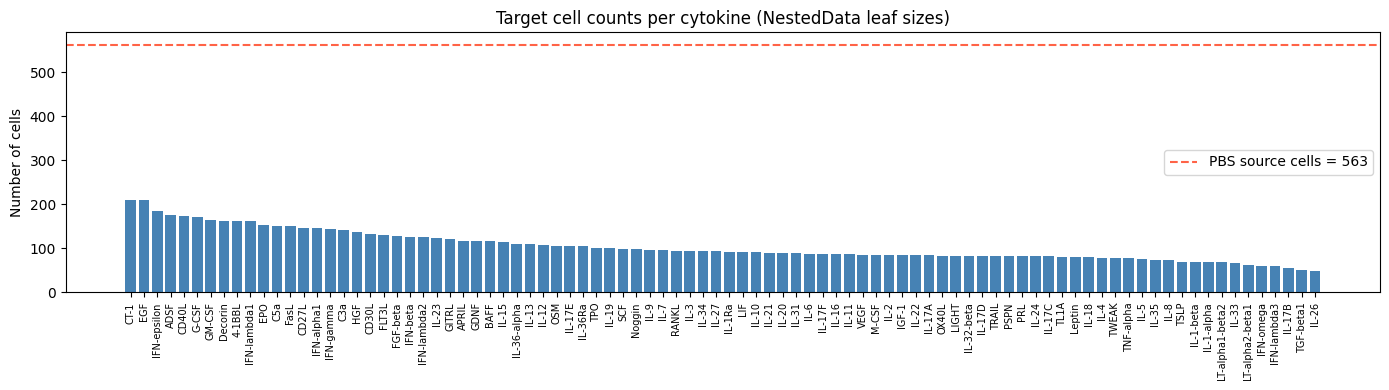

In [15]:
# Summary: cell counts per condition
# Right now, Any cytokine vs PBS data islopsided.

keys = list(inner.mapping.keys())
n_target = [inner[k].n_tgt_obs for k in keys]
n_source = inner[keys[0]].n_src_obs  # PBS cells â€” same for all

cytokine_names = [k[0] for k in keys]
sorted_pairs = sorted(zip(n_target, cytokine_names, strict=False), reverse=True)
n_target_sorted, names_sorted = zip(*sorted_pairs, strict=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(names_sorted)), n_target_sorted, color="steelblue")
ax.axhline(n_source, color="tomato", linestyle="--", label=f"PBS source cells = {n_source}")
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax.set_ylabel("Number of cells")
ax.set_title("Target cell counts per cytokine (NestedData leaf sizes)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Flatten to a list of all MatchedData entries
all_matched = nested_data.flatten()
print(f"Total MatchedData entries: {len(all_matched)}")
print(f"(= {len(inner.mapping)} cytokines, each paired with the same PBS source)")

Total MatchedData entries: 90
(= 90 cytokines, each paired with the same PBS source)


## Extending `DataManager` with cell-type groups

Adding `groups=["cell_type"]` creates a two-level hierarchy:
- __First level__: Cell type
- __Second level__: Cytokine

> **Note:** Similar to how we have ESM2 embeddings for cytokine level, wealso need some kind of embedding for cell type as well. Since there are no cell type embeddings in `adata.uns`, we have to create embeddings for it. We can use `DataManager` to create embeddings of 3 types - __label__, __one-hot__, __functional__. The __functional__ embedding allows you to use your own custom function for creating embeddings

In [17]:
manager_grouped = DataManager(
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
    groups=["cell_type"],
    groups_encoding={"cell_type": "label"},
)

print("Groups:    ", manager_grouped.groups_data_schema.groups)
print("Encoding:  ", manager_grouped.groups_data_schema.groups_encoding)
print("source_key:", manager_grouped.source_key)

Groups:     ['cell_type']
Encoding:   {'cell_type': 'label'}
source_key: ('PBS',)


The dataset has a problem. When we use `groups=["cell_type"]`, we are grouping the cells based on cell type, then in each of these groups, we sub group the cells based on `cytokine` conditions.

Since we are using `PBS` as the source cells, the DataManager expects atleast one cell with `cytokine= 'PBS'` in each of the cell type groups.

In our dataset, cell group `Plasmblast` does not have any `PBC` cells which will give us an error whe compiling data. The best option is to remove cells of cell type Plasmablast.

In [25]:
# Plasmablast has 0 PBS cells and will cause a KeyError -- filter it out
pbs_cell_types = set(adata[adata.obs["treatment"] == "PBS"].obs["cell_type"].unique())
adata_grouped = adata[adata.obs["cell_type"].isin(pbs_cell_types)].copy()

# Warn about cell types with very few PBS cells (present but low-quality source)
pbs_counts = adata_grouped[adata_grouped.obs["treatment"] == "PBS"].obs["cell_type"].value_counts()
low_pbs = pbs_counts[pbs_counts < 10]
if len(low_pbs) > 0:
    print(
        f"The following cell types have fewer than 10 PBS source cells and may produce "
        f"unreliable results: {list(low_pbs.index)}. Consider filtering them out for training."
    )

nested_grouped = manager_grouped.compile_adata(adata_grouped)

print("Top-level keys (cell types):")
for k in nested_grouped.mapping.keys():
    print(f"  {k}  ->  {len(nested_grouped[k].mapping)} conditions")

The following cell types have fewer than 10 PBS source cells and may produce unreliable results: ['MAIT', 'NK CD56bright', 'Treg', 'cDC', 'HSPC', 'ILC', 'pDC']. Consider filtering them out for training.


100%|██████████| 9/9 [00:00<00:00, 1068.22it/s]


Top-level keys (cell types):
  ('CD8 Naive',)  ->  90 conditions
  ('B Naive',)  ->  90 conditions
  ('B Intermediate/Memory',)  ->  82 conditions
  ('CD14 Mono',)  ->  90 conditions
  ('CD4 Naive',)  ->  89 conditions
  ('NK',)  ->  90 conditions
  ('CD4 Memory',)  ->  90 conditions
  ('cDC',)  ->  68 conditions
  ('CD8 Memory',)  ->  90 conditions
  ('CD16 Mono',)  ->  86 conditions
  ('NK CD56bright',)  ->  67 conditions
  ('MAIT',)  ->  73 conditions
  ('Treg',)  ->  55 conditions
  ('ILC',)  ->  8 conditions
  ('HSPC',)  ->  12 conditions
  ('NKT',)  ->  60 conditions
  ('pDC',)  ->  9 conditions


In [19]:
# Inspect a specific cell-type + cytokine combination
cell_type_key = list(nested_grouped.mapping.keys())[0]
print("Cell type key:", cell_type_key)

inner_grouped = nested_grouped[cell_type_key]
cytokine_key = list(inner_grouped.mapping.keys())[0]
print("Cytokine key: ", cytokine_key)

matched = inner_grouped[cytokine_key]
print()
print(f"  target n_obs:  {matched.n_tgt_obs}")
print(f"  source n_obs:  {matched.n_src_obs}")
print(f"  target state:  {matched.target.state_data}")
print(f"  source state:  {matched.source.state_data}")

Cell type key: ('CD8 Naive',)
Cytokine key:  ('4-1BBL',)

  target n_obs:  12
  source n_obs:  27
  target state:  StateData(n_obs=12, spatial_dims=(50,))
  source state:  StateData(n_obs=27, spatial_dims=(50,))


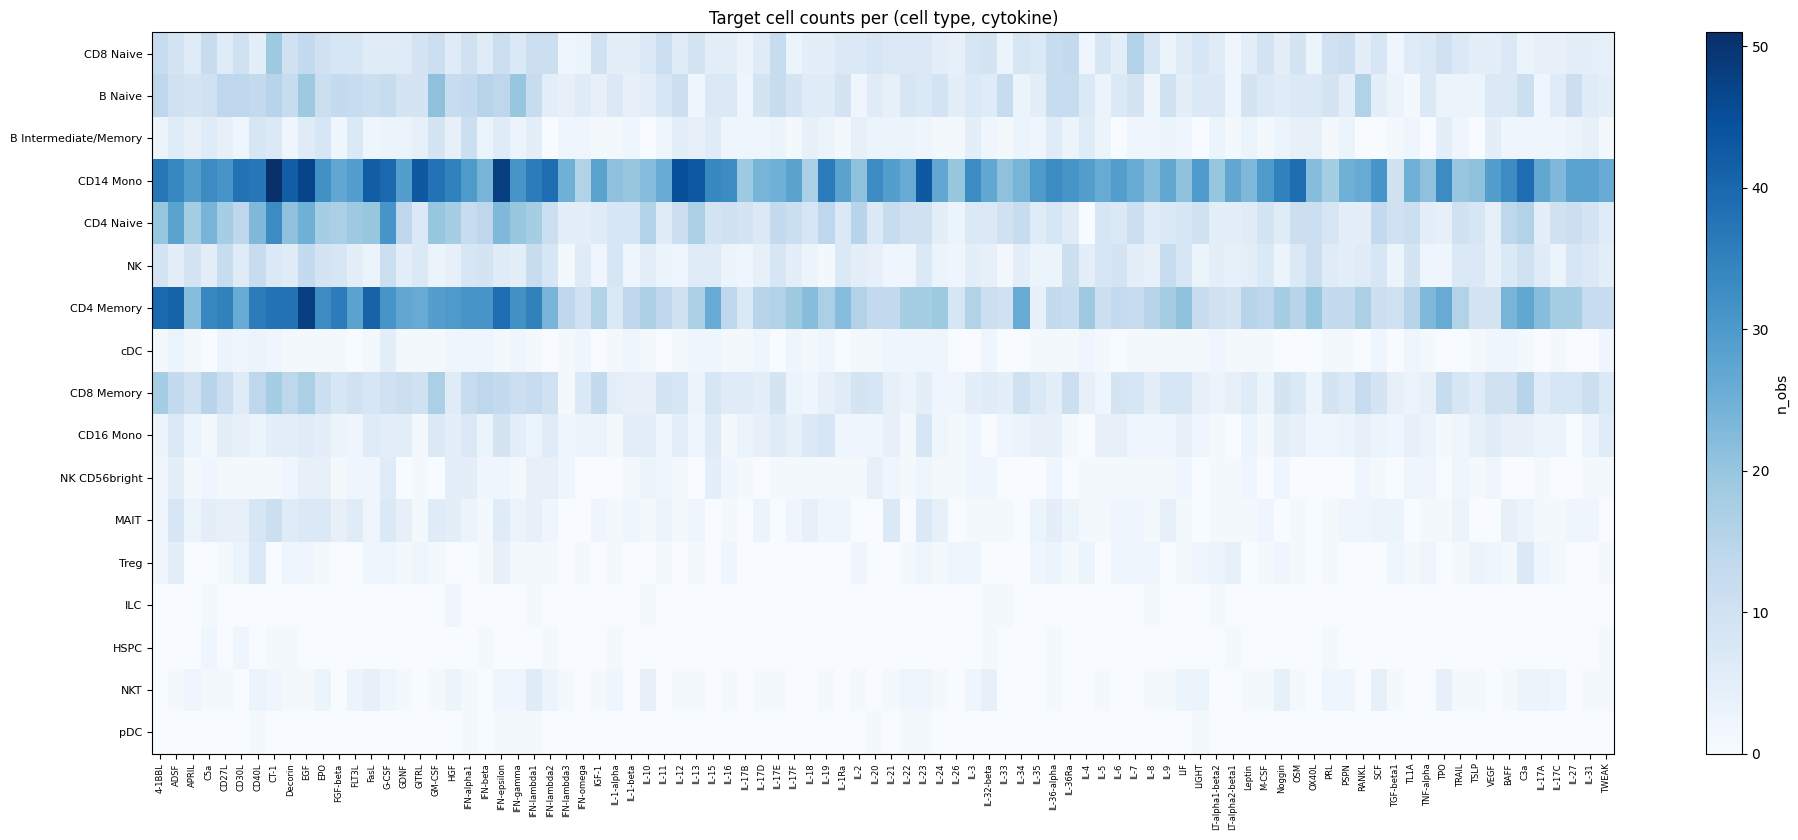

In [20]:
# Heatmap: number of target cells per (cell_type, cytokine)

cell_type_keys = list(nested_grouped.mapping.keys())
cytokine_keys = list(nested_grouped[cell_type_keys[0]].mapping.keys())

matrix = np.zeros((len(cell_type_keys), len(cytokine_keys)), dtype=int)
for i, ct_key in enumerate(cell_type_keys):
    for j, cyt_key in enumerate(cytokine_keys):
        if cyt_key in nested_grouped[ct_key].mapping:
            matrix[i, j] = nested_grouped[ct_key][cyt_key].n_tgt_obs

cell_type_labels = [k[0] for k in cell_type_keys]
cytokine_labels = [k[0] for k in cytokine_keys]

fig, ax = plt.subplots(figsize=(20, max(3, len(cell_type_labels) * 0.5)))
im = ax.imshow(matrix, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(cytokine_labels)))
ax.set_xticklabels(cytokine_labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(cell_type_labels)))
ax.set_yticklabels(cell_type_labels, fontsize=8)
ax.set_title("Target cell counts per (cell type, cytokine)")
plt.colorbar(im, ax=ax, label="n_obs")
plt.tight_layout()
plt.show()

## Extending `DataManager` with `Functional` encoding for cell type groups

> **Note:** The cells below require `DataManager` to expose `groups_encoding_transform_fn` and `groups_encoding_inverse_transform_fn` in its `__init__`. This is already implemented in the `data_module_1` branch but not yet merged into `tutorials`. Once this is done, we can run these cells as well.

The three available encoding strategies for group columns are:
- `"label"` - integer index per class (e.g. `"T cell"` to `2`)
- `"one-hot"` - binary vector per class
- `"functional"` - **We create a custom func**

Here we define a simple custom encoding: map each cell type to a fixed 4-dimensional vector based on its biology (__INCOMPLETE__)

In [ ]:
# Define a custom embedding for each cell type
# Columns: [is_lymphoid, is_myeloid, is_T_cell, is_B_cell]
CELL_TYPE_EMBEDDINGS = {
    "CD4 T": np.array([1, 0, 1, 0], dtype=np.float32),
    "CD8 T": np.array([1, 0, 1, 0], dtype=np.float32),
    "NK": np.array([1, 0, 0, 0], dtype=np.float32),
    "B": np.array([1, 0, 0, 1], dtype=np.float32),
    "Monocyte": np.array([0, 1, 0, 0], dtype=np.float32),
    "DC": np.array([0, 1, 0, 0], dtype=np.float32),
}


def encode_cell_type(cell_type_array):
    """Map an array of cell type strings to a 2D embedding matrix."""
    return np.stack([CELL_TYPE_EMBEDDINGS.get(ct, np.zeros(4, dtype=np.float32)) for ct in cell_type_array])


def decode_cell_type(embedding_matrix):
    """Nearest-neighbour lookup back to cell type string."""
    keys = list(CELL_TYPE_EMBEDDINGS.keys())
    vecs = np.stack(list(CELL_TYPE_EMBEDDINGS.values()))
    dists = np.linalg.norm(embedding_matrix[:, None, :] - vecs[None, :, :], axis=-1)
    return np.array(keys)[np.argmin(dists, axis=1)]

In [ ]:
# NOTE: requires DataManager to expose groups_encoding_transform_fn (data_module_1 branch)
manager_functional = DataManager(
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
    groups=["cell_type"],
    groups_encoding={"cell_type": "functional"},
    groups_encoding_transform_fn={"cell_type": encode_cell_type},
    groups_encoding_inverse_transform_fn={"cell_type": decode_cell_type},
)

In [ ]:
nested_functional = manager_functional.compile_adata(adata)

# Each outer key is a cell type -- inspect one
cell_type_key = list(nested_functional.mapping.keys())[0]
print("Cell type key:", cell_type_key)

inner = nested_functional[cell_type_key]
cytokine_key = list(inner.mapping.keys())[0]
matched = inner[cytokine_key]

# The groups_data on the target distribution holds the functional encoding
groups_data = matched.target_distribution.groups_data
print("Groups data type:", type(groups_data))
print("Encoded cell types (first 5 rows):")
print(groups_data.categorical_covariates.encoded[:5])

## Extending `DataManager` Combinatorial groups: _cell type + donor_

Until now, we only grouped our data based on cell groups. The PBMC dataset has a second meaningful axis: **donor**. Each cell came from one of 3 donors (Donor10, Donor11, Donor12)

Here we put **both cell type and donor into `groups`**, keeping cytokine as the only condition. This creates a 3-level hierarchy:
- **First level (groups)**: `(cell_type, donor)`
- **Second level (conditions)**: `cytokine`

### Data cleaning required

Similar to the problem we face before, the `PBS` lookup happens **within each (cell_type, donor) group**. Any group with zero PBS cells will crash with a `KeyError`. Two cleaning steps are needed:

**Step 1 — Remove Donor12** (1,800 cells)
Donor12 has zero PBS cells

**Step 2 — Remove 6 specific (cell_type, donor) combinations** (34 cells)
These combinations still have zero PBS cells:

| (cell_type, donor) | cells | reason |
|---|---|---|
| (HSPC, Donor11) | 7 | all cytokine-treated, no PBS |
| (ILC, Donor11) | 4 | all cytokine-treated, no PBS |
| (NKT, Donor10) | 15 | all cytokine-treated, no PBS |
| (Plasmablast, Donor10) | 2 | all cytokine-treated, no PBS |
| (Plasmablast, Donor11) | 2 | all cytokine-treated, no PBS |
| (pDC, Donor10) | 4 | all cytokine-treated, no PBS |

Note: HSPC, ILC, NKT, pDC are **not fully removed** — the only pair that has no PBS is `Plasmablast`.

**Total removed: 1,834 cells**


In [21]:
# Remove Donor12 (zero PBS cells for all its cell types)
adata_combined = adata[adata.obs["donor"] != "Donor12"].copy()
print(f"After removing Donor12: {adata_combined.n_obs} cells")

# Remove specific (cell_type, donor) combinations with zero PBS cells
bad_combos = {
    ("HSPC", "Donor11"),
    ("ILC", "Donor11"),
    ("NKT", "Donor10"),
    ("Plasmablast", "Donor10"),
    ("Plasmablast", "Donor11"),
    ("pDC", "Donor10"),
}
mask = adata_combined.obs.apply(lambda r: (r["cell_type"], r["donor"]) in bad_combos, axis=1)
adata_combined = adata_combined[~mask].copy()
print(f"After removing bad (cell_type, donor) combos: {adata_combined.n_obs} cells")
print(f"Remaining donors: {sorted(adata_combined.obs['donor'].unique())}")
print(f"Remaining cell types: {sorted(adata_combined.obs['cell_type'].unique())}")

After removing Donor12: 8200 cells
After removing bad (cell_type, donor) combos: 8166 cells
Remaining donors: ['Donor10', 'Donor11']
Remaining cell types: ['B Intermediate/Memory', 'B Naive', 'CD14 Mono', 'CD16 Mono', 'CD4 Memory', 'CD4 Naive', 'CD8 Memory', 'CD8 Naive', 'HSPC', 'ILC', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Treg', 'cDC', 'pDC']


In [22]:
# Recompute PCA on the filtered data
X_combined = adata_combined.X.toarray() if hasattr(adata_combined.X, "toarray") else np.array(adata_combined.X)
pca_combined = PCATransform(n_components=50)
adata_combined.obsm["X_pca"] = pca_combined.fit_transform(X_combined)

In [23]:
manager_combined = DataManager(
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
    groups=["cell_type", "donor"],
    groups_encoding={"cell_type": "label"},
    groups_reps={"donor": "donor_embeddings"},
)

nested_combined = manager_combined.compile_adata(adata_combined)

print(f"Total (cell_type, donor) groups: {len(nested_combined.mapping)}")
print("First 5 group keys:", list(nested_combined.mapping.keys())[:5])

100%|██████████| 1/1 [00:00<00:00, 415.07it/s]

Total (cell_type, donor) groups: 30
First 5 group keys: [('CD8 Naive', 'Donor10'), ('B Naive', 'Donor10'), ('B Intermediate/Memory', 'Donor10'), ('CD14 Mono', 'Donor10'), ('CD4 Naive', 'Donor10')]


In [24]:
# Pick one group and one cytokine to inspect
group_key = list(nested_combined.mapping.keys())[0]
inner = nested_combined[group_key]
cytokine_key = list(inner.mapping.keys())[0]
matched = inner[cytokine_key]
print(f"Group (cell_type, donor):            {group_key}")
print(f"Cytokine:                            {cytokine_key}")
print(f"Number of cytokine conditions:       {len(inner.mapping)}")

# --- Condition embedding (ESM2 for cytokine) ---
cond = matched.target_distribution.condition_data.categorical_covariates
cytokine_name = cond.ann_df["cytokine"].iloc[0]
esm2_embedding = cond.repr_dict["cytokine_level"][cytokine_name]
print(f"ESM2 embedding for condition {cytokine_name}: shape {np.array(esm2_embedding).shape}")

# --- Group embedding (donor -- pre-computed lookup) ---
gd = matched.target_distribution.groups_data
donor_name = gd.ann_df["donor"].iloc[0]
donor_embedding = gd.repr_dict["donor"][donor_name]
print(f"Donor embedding for group {donor_name}:   shape {np.array(donor_embedding).shape}")

# --- Group encoding (cell type -- label encoded) ---
cell_type_labels = gd.categorical_encoders["cell_type"].transform(gd.ann_df["cell_type"].values.reshape(-1))
print(f"Cell type label for group {group_key[0]}: {cell_type_labels[0]}")

Group (cell_type, donor):            ('CD8 Naive', 'Donor10')
Cytokine:                            ('4-1BBL',)
Number of cytokine conditions:       83
ESM2 embedding for condition 4-1BBL: shape (2560,)
Donor embedding for group Donor10:   shape (2000,)
Cell type label for group CD8 Naive: 7
